In [1]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

import robotic as ry

import data_tools
import sim_wrappers as sim


In [2]:
scene_path = "/home/sayantan/Downloads/fingerRamp.g"
xml_path = "/home/sayantan/repos/tub/proj/explore/configs/fingerRamp.xml"
config_path = "/home/sayantan/repos/tub/proj/explore/configs/fingerRamp_onRamp.h5"


## TODO does not work: free object is not root, config file has q not qpos
#scene_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/scenes/oneFingerBall.yml"
#xml_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/scenes/oneFingerBall.xml"
#config_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/data/fingerBall/configs_oneFingerBall.h5"

In [3]:
from sim_wrappers.mujoco_gym import MujocoGymGoal

env = MujocoGymGoal(
    config_path=config_path,
    xml_path=xml_path,
    scene_path=scene_path,
    feature_map=lambda x: x,
    sparse_r_thr=10.0,
)

env.render_mode = 'rgb_array'

-- initializing MjSim with 1 free objects and joint dimension 3 (mj qpos:10 ctrl:3)


dict_keys(['observation', 'achieved_goal', 'desired_goal']) {'start_id': 6, 'goal_id': 4}


libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations


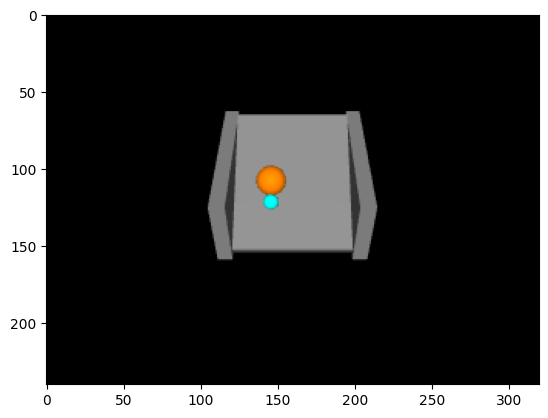

In [4]:
obs_dict, info = env.reset()
print(obs_dict.keys(), info)
frame = env.render()
plt.imshow(frame)

In [5]:
import mediapy as media
frames = []
obs_dict, info = env.reset()
frames.append(env.render())
for i in range(100):
    random_action = action=env.action_space.sample()
    obs_dict, reward, terminated, truncated, info = env.step(random_action)
    frames.append(env.render())

media.show_video(frames, fps=20)


This browser does not support the video tag.


In [6]:
a = np.zeros((5,19))
d = np.ones((5,19))
o = np.zeros((5,38))

info = {}

r = env.compute_reward(a,d,info)

print(r.shape)

(5,)


In [7]:
from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)

We detected your env to be a GoalEnv because `env.compute_reward()` was defined.
If it's not the case, please rename `env.compute_reward()` to something else to avoid False positives.


In [8]:
pi = lambda obs, t : env.action_space.sample()
env.rollout(pi=pi)


total (non-discounted) return: 0.0
